## Completeness limits for Gaia DR3 data

Here I assume that Gaia DR3 is essentially complete in the range of 
**apparent** magnitudes 2 mag < G < 20.5 mag. 

I then calculate the limiting distances, d_min and d_max, where stars with the different **absolute** magnitudes M_G fall into this range. 

I also use completeness information provided by GaiaUnlimited tool. 

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from gaiaunlimited.selectionfunctions import DR3SelectionFunctionTCG
from gaiaunlimited.utils import get_healpix_centers

In [2]:
# Range where Gaia DR3 is complete
mG_up = 2.0
mG_low = 20.5

# Create absolute magnitude grid M_G
MG_up = -11     # bright limit
MG_low = 22     # faint limit  
MG_step = 0.2   # step, mag
MG_bins = np.arange(MG_up, MG_low + MG_step, MG_step) 
MG_bins_c = np.round(MG_bins[:-1] + MG_step/2,1)

# Create distance grid 
r_sphere = 1500 # limiting distance, pc
d_step = 1      # step, pc 
d_bins = np.arange(d_step, r_sphere+d_step, d_step)

In [ ]:

# Convert absolute magnitudes + apparent magnitude limits into distance limits
# Here extinction is neglected

d_lim1 = [10**(0.2*(mG_up - M) + 1) for M in MG_bins_c]   # pc
d_lim2 = [10**(0.2*(mG_low - M) + 1) for M in MG_bins_c]  # pc

MG_lim1 = [MG_bins_c[np.argmin(np.abs(d_lim1 - d))] for d in d_bins]
MG_lim2 = [MG_bins_c[np.argmin(np.abs(d_lim2 - d))] for d in d_bins] 

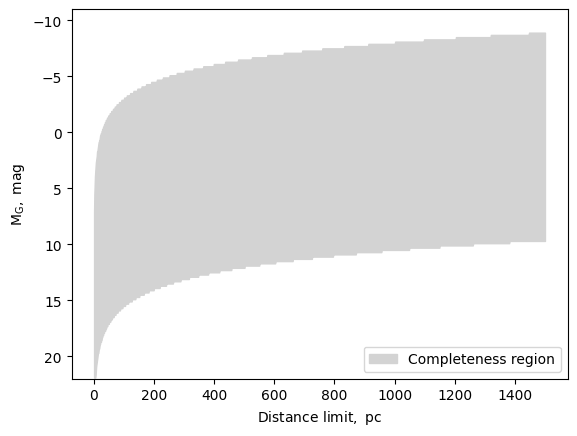

In [4]:
# This is the most useful plot!
# Shows distance limits for M_G bins assuming Gaia 100-% completeness in G_up < G < G_low

f, ax = plt.subplots()
ax.fill_between(d_bins, MG_lim1, MG_lim2, color='lightgrey', label='Completeness region')
ax.set_ylim(MG_low,MG_up)
ax.legend(loc=4)
ax.set_ylabel(r'$\mathrm{M_G,  \ mag}$')
ax.set_xlabel(r'$\mathrm{Distance \ limit,  \ pc}$')
f.savefig('completeness/cmd_gdr3_completeness_limits.png',dpi=300)

# Save calculated distance limits for M_G grid
np.savetxt('./completeness/gdr3_dlim_vs_MG.txt', 
           np.array([np.round(MG_bins[:-1],1),np.round(MG_bins[1:],1),d_lim1,d_lim2]).T,
           fmt='%0.1f %0.1f %0.0f %0.0f',delimiter='\t',
           header=r'GDR3 assumed to be 100% complete for 2 < G < 20.5' +\
                   '\nMG_low [mag],  MG_up [mag], dlim_low [pc],  dlim_up [pc]'
          )

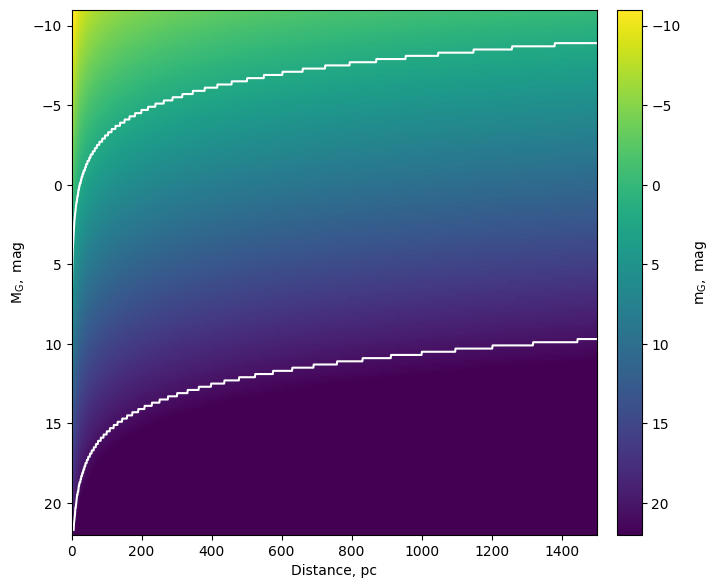

In [6]:
# Another way of showing the same
# Use distances as an input, calculate apparent magnitudes and compare to the limits 

mG = np.zeros((len(d_bins), len(MG_bins_c)))

for i in range(len(MG_bins_c)):
    for k in range(len(d_bins)):
        mG[k, i] = MG_bins_c[i] + 5*np.log10(d_bins[k]/10)  

MG1, MG2 = [], []
for k in range(len(d_bins)):
    i1 = np.where(mG[k, :] < mG_up)[0]
    i2 = np.where(mG[k, :] > mG_low)[0]
    MG1.append(MG_bins_c[i1][-1])
    if len(i2) > 0:
        MG2.append(MG_bins_c[i2][0])
    else:
        MG2.append(None)

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(mG.T,interpolation='none',extent=[0,r_sphere,MG_low,MG_up],
               cmap='viridis_r',vmin=MG_up,vmax=MG_low
               )
ax.plot(d_bins, MG1, color='w', label='M_G < ' + str(mG_up))
ax.plot(d_bins, MG2, color='w', label='M_G > ' + str(mG_low))
ax.set_xlabel('Distance, pc')   
ax.set_ylabel(r'$\mathrm{M_G, \ mag}$')
ax.set_aspect((r_sphere)/(MG_low - MG_up))

fig.subplots_adjust(bottom=0.18,left=0.08,right=0.94,top=0.93)
pos = ax.get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{m_{G}, \ mag}$',labelpad=10)
cax.invert_yaxis()

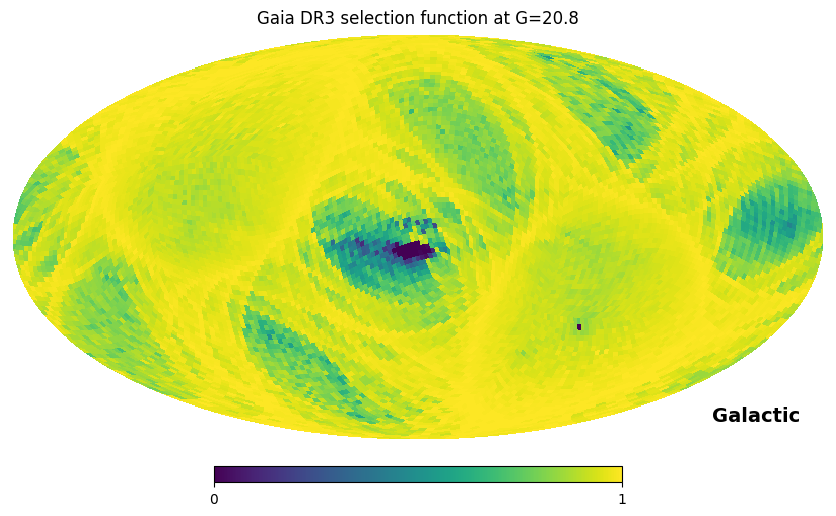

In [14]:
# Check completeness over skymap

G = 20.8

mapHpx7 = DR3SelectionFunctionTCG()
coords_of_centers = get_healpix_centers(5)
gmag = np.ones_like(coords_of_centers) * G
completeness = mapHpx7.query(coords_of_centers,gmag)
hp.mollview(completeness,coord=['Celestial','Galactic'],
            title=f'Gaia DR3 selection function at G={G}',
            min=0,max=1)